In [39]:
### import necessary packages

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [60]:
### import data

data= pd.read_csv("./brca_metabric_clinical_data.tsv", sep="\t")

In [61]:
### feature selection

# list of featires to keep
keep_columns=["Age at Diagnosis", 
              "Cancer Type Detailed", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "ER Status",
              "PR Status",
              "HER2 Status",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster",
              "Overall Survival (Months)"]

# remove other features
data = data[keep_columns].copy()

# confirm removal
print(data.columns)

# remove sapmeles where Overall Survival is na
data = data.dropna(subset=["Overall Survival (Months)"])

# check shape
print(data.shape)

Index(['Age at Diagnosis', 'Cancer Type Detailed', 'Inferred Menopausal State',
       'Tumor Size', 'Lymph nodes examined positive', 'ER Status', 'PR Status',
       'HER2 Status', '3-Gene classifier subtype',
       'Pam50 + Claudin-low subtype', 'Integrative Cluster',
       'Overall Survival (Months)'],
      dtype='str')
(1981, 12)


In [62]:
### group rare cancer types together

top3 = data["Cancer Type Detailed"].value_counts().nlargest(3).index

data["Cancer Type Grouped"] = data["Cancer Type Detailed"].apply(
    lambda x: x if x in top3 else "Other")

print(data["Cancer Type Grouped"].value_counts())

Cancer Type Grouped
Breast Invasive Ductal Carcinoma             1538
Breast Mixed Ductal and Lobular Carcinoma     211
Breast Invasive Lobular Carcinoma             146
Other                                          86
Name: count, dtype: int64


In [63]:
### create IHC subtype based on ER/PR/HER2 status

def ihc_subtype(row):
    er = str(row.get("ER Status", "")).strip().lower()
    pr = str(row.get("PR Status", "")).strip().lower()
    her2 = str(row.get("HER2 Status", "")).strip().lower()

    if her2 == "positive":
        return "HER2"
    elif er == "positive" or pr == "positive":
        return "Luminal"
    elif er == "negative" and pr == "negative" and her2 == "negative":
        return "Triple Negative"
    else:
        return "Unknown"

if "PR Status" not in data.columns:
    print("Warning: PR Status is missing. Re-run cell 3 first to include PR Status in keep_columns.")

data["IHC Subtype"] = data.apply(ihc_subtype, axis=1)

print(data["IHC Subtype"].value_counts(dropna=False))

# Check for missing values in the new feature
print(data["IHC Subtype"].isna().sum())

#delate columns "ER Status", "PR Status", "HER2 Status"
data = data.drop(columns=["ER Status", "PR Status", "HER2 Status"])

IHC Subtype
Luminal            1414
Triple Negative     320
HER2                247
Name: count, dtype: int64
0


In [64]:
### discretize overall survival (months) into 2 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]<60:
        data.loc[index, "Survival Duration"] = "<5 years"
    else:
        data.loc[index, "Survival Duration"] = "5+ years"

In [65]:
### split predictors and response

predictors=["Age at Diagnosis", 
              "Cancer Type Grouped", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "IHC Subtype",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster"]

x= data[predictors]
y=data["Survival Duration"]

In [66]:
### split into test and train data 
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42)

In [67]:
### statistical imputation

# check NaNs
print(x_train.isna().sum())
print(x_test.isna().sum())

# impute menopausal status based on age
mask = x_train["Inferred Menopausal State"].isna()
x_train.loc[mask, "Inferred Menopausal State"] = np.where(
    x_train.loc[mask, "Age at Diagnosis"] < 52,
    "Pre",
    "Post")

# impute tumor size from training median
tumor_size_median = x_train["Tumor Size"].median()
x_train["Tumor Size"] = x_train["Tumor Size"].fillna(tumor_size_median)
x_test["Tumor Size"] = x_test["Tumor Size"].fillna(tumor_size_median)

# impute lymph nodes from training median
lymph_node_median = x_train["Lymph nodes examined positive"].median()
x_train["Lymph nodes examined positive"] = x_train["Lymph nodes examined positive"].fillna(lymph_node_median)
x_test["Lymph nodes examined positive"] = x_test["Lymph nodes examined positive"].fillna(lymph_node_median)

# impute 3-gene classifier using knn
three_gene_mode = x_train["3-Gene classifier subtype"].mode()[0]
x_train["3-Gene classifier subtype"] = x_train["3-Gene classifier subtype"].fillna(three_gene_mode)
x_test["3-Gene classifier subtype"] = x_test["3-Gene classifier subtype"].fillna(three_gene_mode)

# impute Pam50 using knn
pam50_mode = x_train["Pam50 + Claudin-low subtype"].mode()[0]
x_train["Pam50 + Claudin-low subtype"] = x_train["Pam50 + Claudin-low subtype"].fillna(pam50_mode)
x_test["Pam50 + Claudin-low subtype"] = x_test["Pam50 + Claudin-low subtype"].fillna(pam50_mode)

# impute IntCluster using knn
int_cluster_mode = x_train["Integrative Cluster"].mode()[0]
x_train["Integrative Cluster"] = x_train["Integrative Cluster"].fillna(int_cluster_mode)
x_test["Integrative Cluster"] = x_test["Integrative Cluster"].fillna(int_cluster_mode)

Age at Diagnosis                   0
Cancer Type Grouped                0
Inferred Menopausal State          1
Tumor Size                        22
Lymph nodes examined positive     57
IHC Subtype                        0
3-Gene classifier subtype        176
Pam50 + Claudin-low subtype        1
Integrative Cluster                1
dtype: int64
Age at Diagnosis                  0
Cancer Type Grouped               0
Inferred Menopausal State         0
Tumor Size                        4
Lymph nodes examined positive    19
IHC Subtype                       0
3-Gene classifier subtype        41
Pam50 + Claudin-low subtype       0
Integrative Cluster               0
dtype: int64


In [68]:
### confirm NaNs are removed

print(x_train.isna().sum())
print(x_test.isna().sum())

Age at Diagnosis                 0
Cancer Type Grouped              0
Inferred Menopausal State        0
Tumor Size                       0
Lymph nodes examined positive    0
IHC Subtype                      0
3-Gene classifier subtype        0
Pam50 + Claudin-low subtype      0
Integrative Cluster              0
dtype: int64
Age at Diagnosis                 0
Cancer Type Grouped              0
Inferred Menopausal State        0
Tumor Size                       0
Lymph nodes examined positive    0
IHC Subtype                      0
3-Gene classifier subtype        0
Pam50 + Claudin-low subtype      0
Integrative Cluster              0
dtype: int64


In [69]:
### seperate x train and x test for each model

# model 1- baseline
x1=["Age at Diagnosis", 
    "Cancer Type Grouped", 
    "Inferred Menopausal State", 
    "Tumor Size",
    "Lymph nodes examined positive",
    "IHC Subtype"]
x1_train= x_train[x1]
x1_test= x_test[x1]

# model 2- baseline + 3-gene
x2= x1 + ["3-Gene classifier subtype"]
x2_train= x_train[x2]
x2_test= x_test[x2]

# model 3- baseline + Pam 50
x3= x1 + ["Pam50 + Claudin-low subtype"]
x3_train= x_train[x3]
x3_test= x_test[x3]

# model 4 - baseline + integrative clusters
x4= x1 + ["Integrative Cluster"]
x4_train= x_train[x4]
x4_test= x_test[x4]

# model 5- 3-gene
x5= ["3-Gene classifier subtype"]
x5_train= x_train[x5]
x5_test= x_test[x5]

# model 6- Pam 50 
x6= ["Pam50 + Claudin-low subtype"]
x6_train= x_train[x6]
x6_test= x_test[x6]

# model 7- Integrative clusters
x7= ["Integrative Cluster"]
x7_train= x_train[x7]
x7_test= x_test[x7]

In [70]:
###  Remove NC (not classified) from x3 and x6

# Training set
mask_train = x3_train["Pam50 + Claudin-low subtype"] != "NC"
x3_train = x3_train[mask_train]
y3_train = y_train[mask_train]

mask_train = x6_train["Pam50 + Claudin-low subtype"] != "NC"
x6_train = x6_train[mask_train]
y6_train = y_train[mask_train]

# Test set
mask_test = x3_test["Pam50 + Claudin-low subtype"] != "NC"
x3_test = x3_test[mask_test]
y3_test = y_test[mask_test]

mask_test = x6_test["Pam50 + Claudin-low subtype"] != "NC"
x6_test = x6_test[mask_test]
y6_test = y_test[mask_test]

In [71]:
### One hot encode

x1_train = pd.get_dummies(x1_train)
x1_test = pd.get_dummies(x1_test)

x2_train = pd.get_dummies(x2_train)
x2_test = pd.get_dummies(x2_test)

x3_train = pd.get_dummies(x3_train)
x3_test = pd.get_dummies(x3_test)

x4_train = pd.get_dummies(x4_train)
x4_test = pd.get_dummies(x4_test)

x5_train = pd.get_dummies(x5_train)
x5_test = pd.get_dummies(x5_test)

x6_train = pd.get_dummies(x6_train)
x6_test = pd.get_dummies(x6_test)

x7_train = pd.get_dummies(x7_train)
x7_test = pd.get_dummies(x7_test)

In [72]:
### establish RandomForest models

# model 1
rf1 = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced_subsample')

# model 2
rf2 = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced_subsample')

# model 3
rf3 = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced_subsample')

# model 4
rf4 = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced_subsample')

# model 5
rf5 = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced_subsample')

# model 6
rf6 = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced_subsample')

# model 7
rf7 = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced_subsample')


In [73]:
### fit models 

# model 1
rf1.fit(x1_train, y_train)

# model 2
rf2.fit(x2_train, y_train)

# model 3
rf3.fit(x3_train, y3_train)

# model 4
rf4.fit(x4_train, y_train)

# model 5
rf5.fit(x5_train, y_train)

# model 6
rf6.fit(x6_train, y6_train)

# model 7
rf7.fit(x7_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchang

In [74]:
### make predictions

# model 1
y1_pred = rf1.predict(x1_test)

# model 2
y2_pred = rf2.predict(x2_test)

# model 3
y3_pred = rf3.predict(x3_test)

# model 4
y4_pred = rf4.predict(x4_test)

# model 5
y5_pred = rf5.predict(x5_test)

# model 6
y6_pred = rf6.predict(x6_test)

# model 7
y7_pred = rf7.predict(x7_test)

In [75]:
### evaluate models

# model 1
print("Accuracy:", accuracy_score(y_test, y1_pred))
print(classification_report(y_test, y1_pred))

# model 2
print("Accuracy:", accuracy_score(y_test, y2_pred))
print(classification_report(y_test, y2_pred))

# model 3
print("Accuracy:", accuracy_score(y3_test, y3_pred))
print(classification_report(y3_test, y3_pred))

# model 4
print("Accuracy:", accuracy_score(y_test, y4_pred))
print(classification_report(y_test, y4_pred))

# model 5
print("Accuracy:", accuracy_score(y_test, y5_pred))
print(classification_report(y_test, y5_pred))

# model 6
print("Accuracy:", accuracy_score(y6_test, y6_pred))
print(classification_report(y6_test, y6_pred))

# model 7
print("Accuracy:", accuracy_score(y_test, y7_pred))
print(classification_report(y_test, y7_pred))

Accuracy: 0.7229219143576826
              precision    recall  f1-score   support

    5+ years       0.86      0.76      0.80       299
    <5 years       0.46      0.62      0.53        98

    accuracy                           0.72       397
   macro avg       0.66      0.69      0.67       397
weighted avg       0.76      0.72      0.74       397

Accuracy: 0.7229219143576826
              precision    recall  f1-score   support

    5+ years       0.86      0.76      0.80       299
    <5 years       0.45      0.61      0.52        98

    accuracy                           0.72       397
   macro avg       0.66      0.69      0.66       397
weighted avg       0.76      0.72      0.74       397

Accuracy: 0.7468354430379747
              precision    recall  f1-score   support

    5+ years       0.87      0.78      0.82       297
    <5 years       0.49      0.64      0.56        98

    accuracy                           0.75       395
   macro avg       0.68      0.71      0.

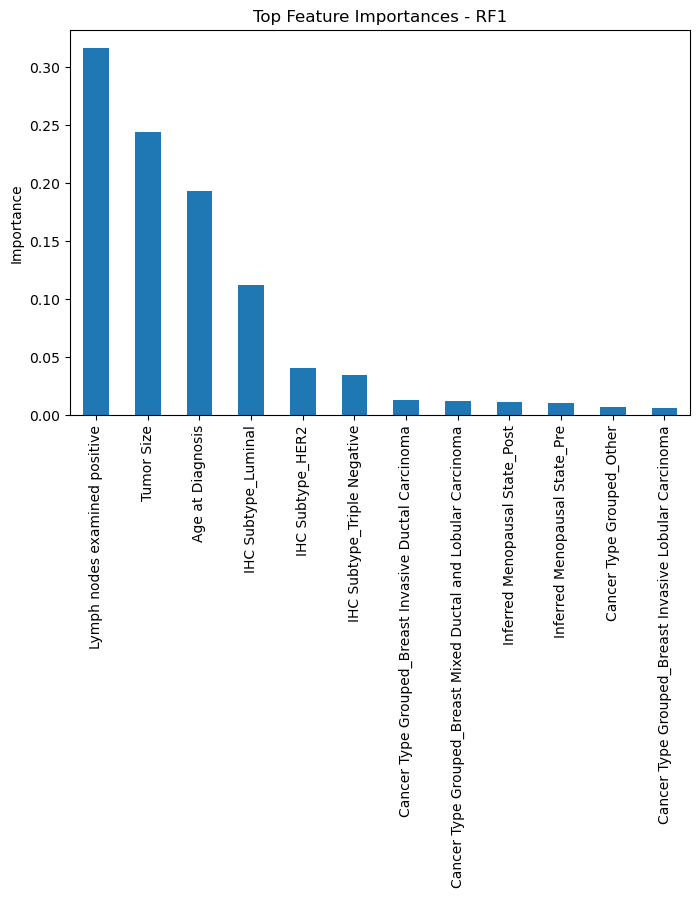

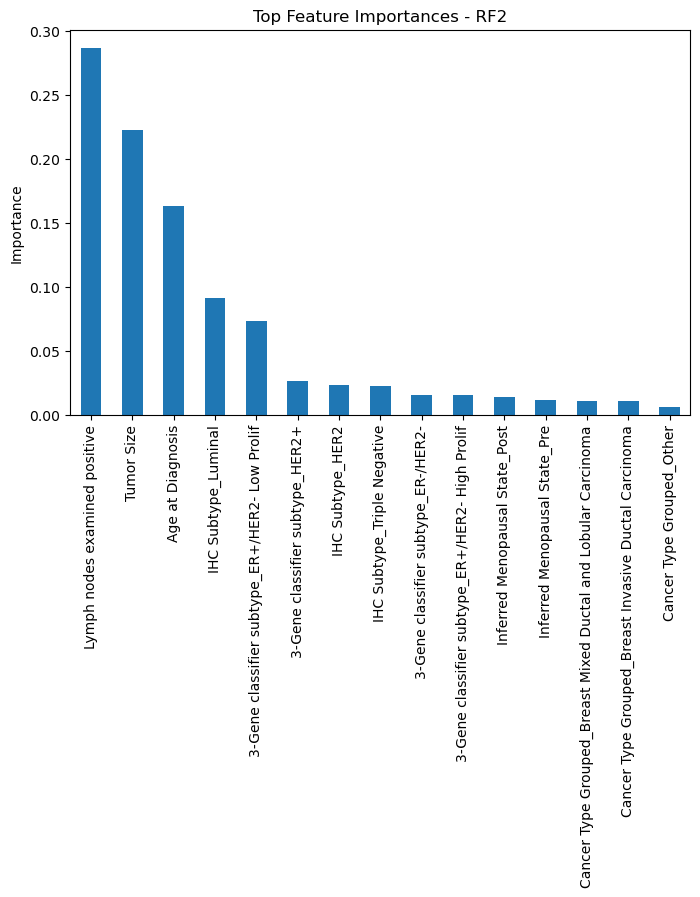

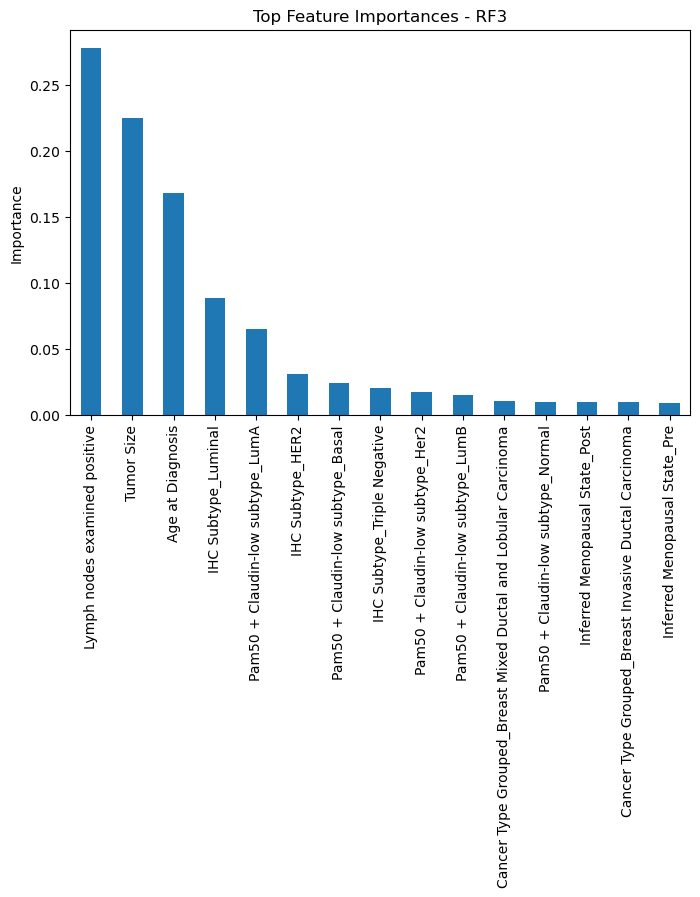

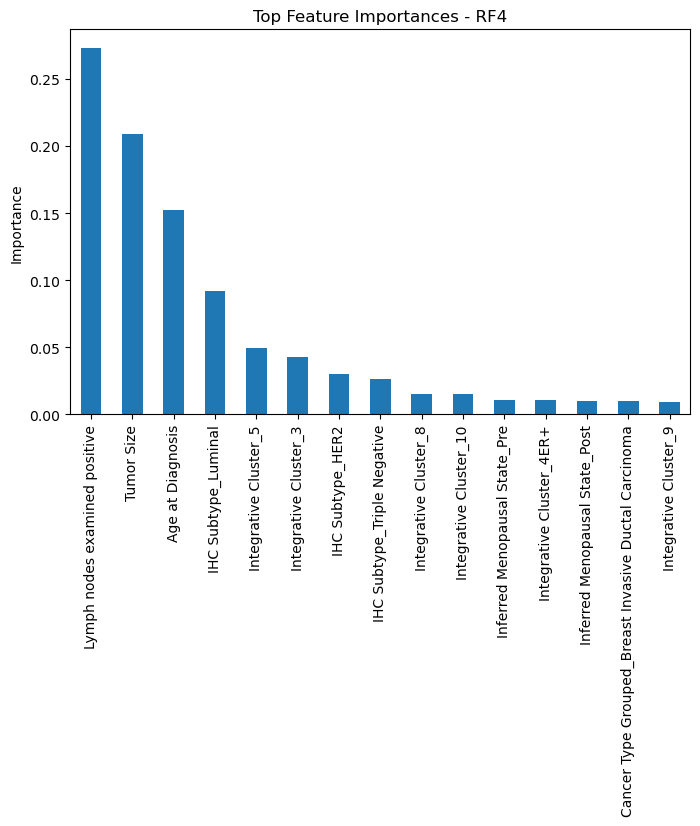

In [76]:
### plot most important features

# model 1
importances1 = pd.Series(rf1.feature_importances_, index=x1_train.columns)
top_features1 = importances1.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_features1.plot(kind="bar")
plt.title("Top Feature Importances - RF1")
plt.ylabel("Importance")
plt.show()

# model 2
importances2 = pd.Series(rf2.feature_importances_, index=x2_train.columns)
top_features2 = importances2.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_features2.plot(kind="bar")
plt.title("Top Feature Importances - RF2")
plt.ylabel("Importance")
plt.show()

# model 3
importances3 = pd.Series(rf3.feature_importances_, index=x3_train.columns)
top_features3 = importances3.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_features3.plot(kind="bar")
plt.title("Top Feature Importances - RF3")
plt.ylabel("Importance")
plt.show()

# model 4
importances4 = pd.Series(rf4.feature_importances_, index=x4_train.columns)
top_features4 = importances4.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_features4.plot(kind="bar")
plt.title("Top Feature Importances - RF4")
plt.ylabel("Importance")
plt.show()

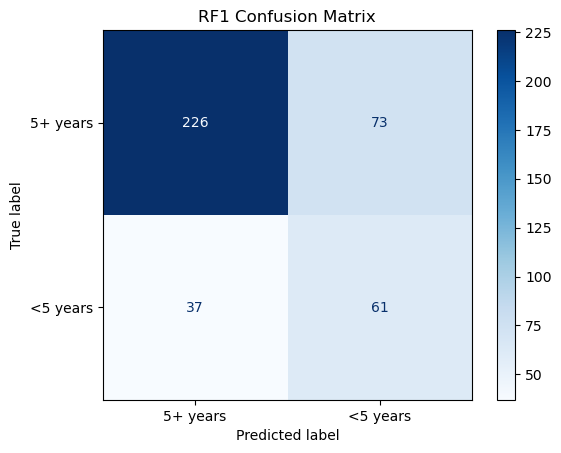

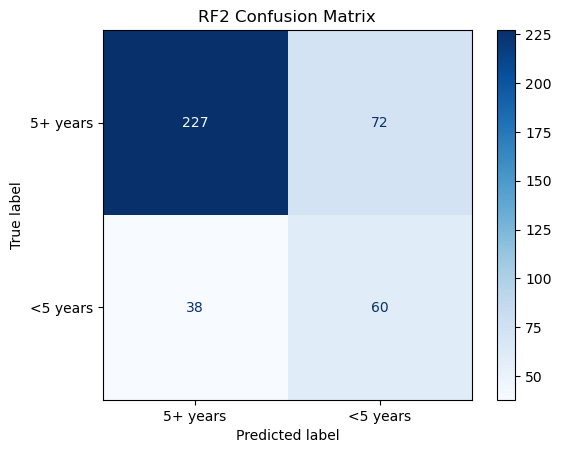

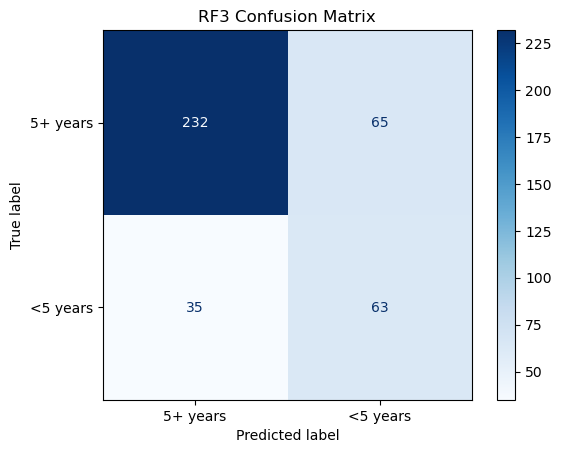

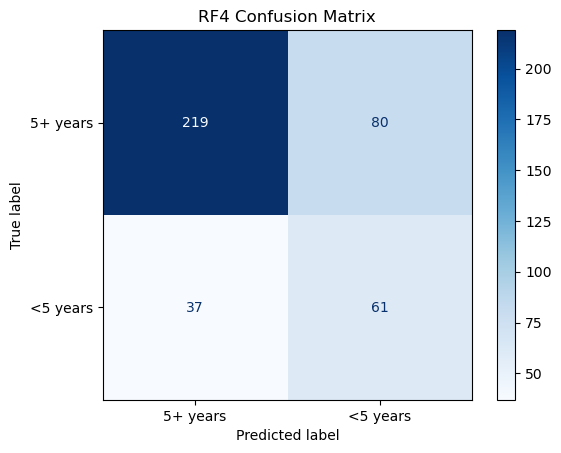

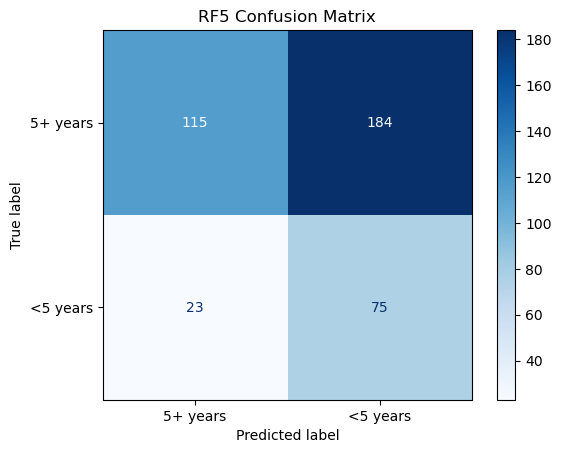

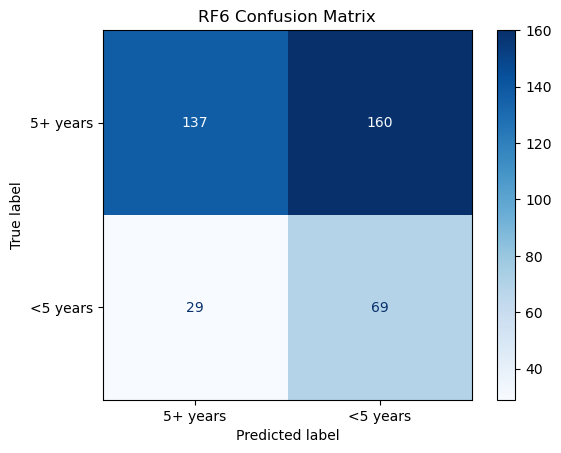

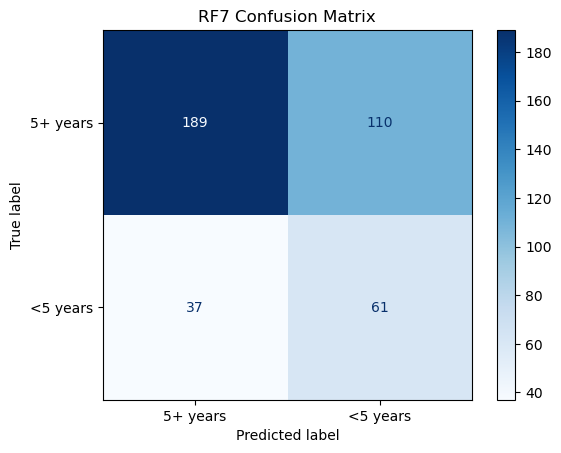

In [77]:
### confusion matricies

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y1_pred,
    cmap="Blues")
plt.title("RF1 Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y2_pred,
    cmap="Blues")
plt.title("RF2 Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y3_test,
    y3_pred,
    cmap="Blues")
plt.title("RF3 Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y4_pred,
    cmap="Blues")
plt.title("RF4 Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y5_pred,
    cmap="Blues")
plt.title("RF5 Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y6_test,
    y6_pred,
    cmap="Blues")
plt.title("RF6 Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y7_pred,
    cmap="Blues")
plt.title("RF7 Confusion Matrix")
plt.show()